# Attention Analysis: Applicable-Only vs Full Rulebook (gpt-oss-120b)

Both conditions use the same model (`gpt-oss-120b`) on the same 20 problems.

| Condition | Rulebook shown to model | Segments tracked | Steps captured |
|---|---|---|---|
| `full` | All rules (73 segments) | 73 (28 applicable + 45 non-applicable) | All generation steps |
| `applicable_only` | Applicable rules only (~26 segments) | ~26 (all applicable) | Prefill only† |

† The 120b model uses a Triton kernel for autoregressive token generation that bypasses `torch.nn.functional.softmax`, so only the prefill pass is captured in the applicable_only condition. **For a fair comparison all analyses use the prefill step only.**

The 120b model also has a double-module pattern in its attention layers — every other entry from `find_attention_modules` is a wrapper that captures auxiliary ops rather than real attention weights. Real layers are auto-detected and used throughout.

In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

RESULTS_ROOT = Path("../results/attention_analysis/openai_gpt-oss-120b/airline")
FULL_DIR     = RESULTS_ROOT / "comp_0"
APP_DIR      = RESULTS_ROOT / "comp_0_applicable_only"
FIGURES_DIR  = APP_DIR / "figures"
FIGURES_DIR.mkdir(exist_ok=True)

def load_samples(d):
    files = sorted(Path(d).glob("[0-9]*.json"), key=lambda p: int(p.stem))
    return [json.loads(f.read_text()) for f in files]

full_samples = load_samples(FULL_DIR)
app_samples  = load_samples(APP_DIR)
full_summary = json.loads((FULL_DIR / "summary.json").read_text())
app_summary  = json.loads((APP_DIR  / "summary.json").read_text())

print(f"Full rulebook  : {len(full_samples)} samples, {full_samples[0]['num_segments']} segments, {full_samples[0]['num_steps']} steps (sample 0)")
print(f"Applicable only: {len(app_samples)} samples, avg {np.mean([s['num_segments'] for s in app_samples]):.1f} segments, {app_samples[0]['num_steps']} step (prefill only)")

Full rulebook  : 20 samples, 73 segments, 1899 steps (sample 0)
Applicable only: 20 samples, avg 26.0 segments, 1 step (prefill only)


## 1. Real layer detection

The 120b model has 36 entries in `find_attention_modules`, but alternating entries are outer wrapper modules that intercept only auxiliary softmax ops. Odd-indexed entries are the real attention layers.

In [2]:
num_layers = full_samples[0]["num_layers"]  # 36

# Use full condition layer sums to detect real layers
_avg_sums = np.mean([
    np.array(s["attention_per_layer_segment"]).sum(axis=1)
    for s in full_samples
], axis=0)

_even = _avg_sums[::2].mean()
_odd  = _avg_sums[1::2].mean()

if _odd > 50 * max(_even, 1e-15):
    real_layers = np.arange(1, num_layers, 2)
elif _even > 50 * max(_odd, 1e-15):
    real_layers = np.arange(0, num_layers, 2)
else:
    real_layers = np.arange(num_layers)

print(f"Real layers: {real_layers.tolist()} ({len(real_layers)} of {num_layers})")
print(f"Even-layer mean attention: {_even:.5f}")
print(f"Odd-layer mean attention:  {_odd:.5f}")

Real layers: [1, 3, 5, 7, 9, 11, 13, 15, 17, 19, 21, 23, 25, 27, 29, 31, 33, 35] (18 of 36)
Even-layer mean attention: 0.00014
Odd-layer mean attention:  0.10269


## 2. Load prefill attention from NPZ cubes (full condition)

The full condition captures all generation steps, but we extract only step 0 (prefill) to match the applicable_only condition.

In [3]:
def load_prefill_attn(sample_dir, sample, real_layers):
    """Load NPZ cube and return prefill attention averaged over real layers → [segments]."""
    npz = np.load(sample_dir / f"{sample['sample_idx']}_attention.npz")
    cube = npz["attention"]                      # [layers, steps, segments]
    return cube[real_layers, 0, :].mean(axis=0)  # [segments]

# Full: prefill attention per segment → [20, 73]
full_prefill = np.stack([
    load_prefill_attn(FULL_DIR, s, real_layers) for s in full_samples
])

# Applicable-only: ragged (each sample has different segment count) → list of arrays
app_prefill = [
    np.array(s["attention_per_layer_segment"])[real_layers].mean(axis=0)
    for s in app_samples
]

print(f"full_prefill shape: {full_prefill.shape}")
print(f"app_prefill: list of {len(app_prefill)} arrays, lengths {[len(a) for a in app_prefill[:5]]} ...")

full_prefill shape: (20, 73)
app_prefill: list of 20 arrays, lengths [26, 27, 27, 25, 27] ...


## 3. Accuracy

In [4]:
is_correct_full = np.array([s["is_correct"] for s in full_samples])
is_correct_app  = np.array([s["is_correct"] for s in app_samples])

summary_rows = []
for label, samples, is_correct in [
    ("full",           full_samples, is_correct_full),
    ("applicable_only", app_samples,  is_correct_app),
]:
    summary_rows.append({
        "condition":       label,
        "accuracy":        f"{is_correct.mean():.0%}",
        "correct":         int(is_correct.sum()),
        "incorrect":       int((~is_correct).sum()),
        "avg_segments":    f"{np.mean([s['num_segments'] for s in samples]):.1f}",
        "avg_input_tokens":f"{np.mean([s['input_length_tokens'] for s in samples]):.0f}",
    })

pd.DataFrame(summary_rows).set_index("condition")

,accuracy,correct,incorrect,avg_segments,avg_input_tokens
condition,,,,,
full,55%,11,9,73.0,5100
applicable_only,50%,10,10,26.0,1819


## 4. Applicable vs non-applicable attention (full condition, prefill)

In the full condition the model sees both applicable and non-applicable rules. We measure how much prefill attention lands on each group.

In [5]:
seg_names_full = np.array(full_samples[0]["segment_names"])
app_mask_full  = np.array(full_samples[0]["segment_is_applicable"])
ntok_full      = np.array(full_samples[0]["segment_num_tokens"])

# Per-sample applicable/non-applicable prefill attention
full_app_total = full_prefill[:, app_mask_full].sum(axis=1)
full_non_total = full_prefill[:, ~app_mask_full].sum(axis=1)
full_app_ptok  = full_app_total / ntok_full[app_mask_full].sum()
full_non_ptok  = full_non_total / ntok_full[~app_mask_full].sum()
full_app_frac  = full_app_total / (full_app_total + full_non_total)

print(f"Applicable segments:     {app_mask_full.sum()} / {len(app_mask_full)}")
print(f"Mean applicable fraction of prefill attention: {full_app_frac.mean():.1%} ± {full_app_frac.std():.1%}")
print(f"Mean app per-token:  {full_app_ptok.mean():.3e}")
print(f"Mean non per-token:  {full_non_ptok.mean():.3e}")
print(f"Per-token ratio:     {(full_app_ptok / np.maximum(full_non_ptok, 1e-12)).mean():.2f}x")

Applicable segments:     28 / 73
Mean applicable fraction of prefill attention: 49.5% ± 0.1%
Mean app per-token:  1.677e-04
Mean non per-token:  1.043e-04
Per-token ratio:     1.61x


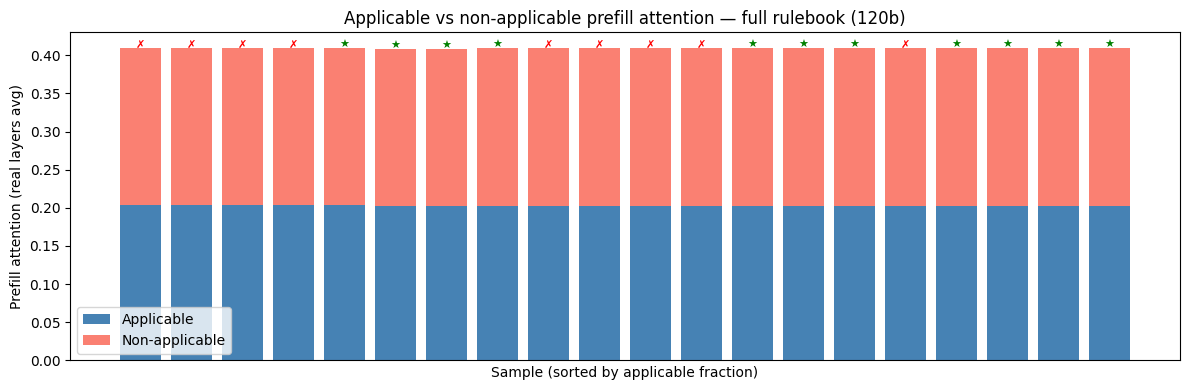

In [6]:
# Stacked bar: applicable vs non-applicable per sample, sorted by applicable fraction
order = np.argsort(full_app_frac)[::-1]

fig, ax = plt.subplots(figsize=(12, 4))
x = np.arange(len(full_samples))
ax.bar(x, full_app_total[order],                              color="steelblue", label="Applicable")
ax.bar(x, full_non_total[order], bottom=full_app_total[order], color="salmon",   label="Non-applicable")
for i, idx in enumerate(order):
    marker = "★" if is_correct_full[idx] else "✗"
    ax.text(i, (full_app_total + full_non_total)[order[i]] + 0.0003,
            marker, ha="center", fontsize=8,
            color="green" if is_correct_full[idx] else "red")
ax.set_xticks([])
ax.set_xlabel("Sample (sorted by applicable fraction)")
ax.set_ylabel("Prefill attention (real layers avg)")
ax.set_title("Applicable vs non-applicable prefill attention — full rulebook (120b)")
ax.legend()
plt.tight_layout()
fig.savefig(FIGURES_DIR / "full_app_vs_non_prefill.png", dpi=150, bbox_inches="tight")
plt.show()

## 5. Per-segment attention: applicable_only (prefill)

With only applicable rules in the prompt, all attention is on relevant content. We look at which segment types attract the most attention.

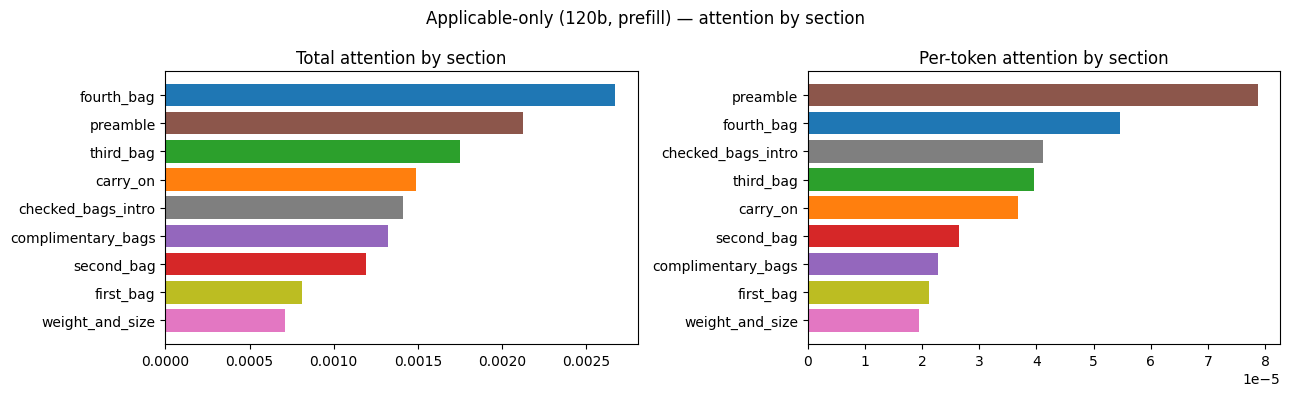

In [7]:
from collections import defaultdict

seg_attn_app = defaultdict(list)
seg_ntok_app = defaultdict(list)

for s, prefill in zip(app_samples, app_prefill):
    for name, attn, ntok in zip(s["segment_names"], prefill, s["segment_num_tokens"]):
        seg_attn_app[name].append(float(attn))
        seg_ntok_app[name].append(ntok)

seg_df = pd.DataFrame({
    "segment":   list(seg_attn_app.keys()),
    "mean_attn": [np.mean(v) for v in seg_attn_app.values()],
    "mean_ntok": [np.mean(v) for v in seg_ntok_app.values()],
    "n_samples": [len(v) for v in seg_attn_app.values()],
})
seg_df["attn_per_tok"] = seg_df["mean_attn"] / seg_df["mean_ntok"]
seg_df["section"]      = seg_df["segment"].str.split("/").str[0]
seg_df = seg_df.sort_values("mean_attn", ascending=False).reset_index(drop=True)

sections = seg_df["section"].unique()
palette  = plt.cm.tab10.colors
sec_color = {s: palette[i % len(palette)] for i, s in enumerate(sections)}

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, col, title in zip(
    axes,
    ["mean_attn", "attn_per_tok"],
    ["Total attention by section", "Per-token attention by section"],
):
    sec_vals = seg_df.groupby("section")[col].mean().sort_values(ascending=True)
    ax.barh(sec_vals.index, sec_vals.values,
            color=[sec_color[s] for s in sec_vals.index])
    ax.set_title(title)

plt.suptitle("Applicable-only (120b, prefill) — attention by section")
plt.tight_layout()
fig.savefig(FIGURES_DIR / "app_only_section_attn.png", dpi=150, bbox_inches="tight")
plt.show()

## 6. Segment-level comparison: same applicable segments, both conditions

We match segments that appear in **both** conditions (the applicable segments). For each such segment we compare its prefill attention in the full vs applicable_only prompt.

In [8]:
# For each sample, match applicable segment attention between conditions
matched_rows = []
for idx, (s_full, s_app, pf_full, pf_app) in enumerate(
    zip(full_samples, app_samples, full_prefill, app_prefill)
):
    # Map name → attention for each condition
    full_name_attn = dict(zip(s_full["segment_names"], pf_full))
    app_name_attn  = dict(zip(s_app["segment_names"],  pf_app))
    app_name_ntok  = dict(zip(s_app["segment_names"],  s_app["segment_num_tokens"]))

    shared = set(full_name_attn) & set(app_name_attn)
    for name in shared:
        matched_rows.append({
            "sample_idx":    idx,
            "segment":       name,
            "section":       name.split("/")[0],
            "attn_full":     float(full_name_attn[name]),
            "attn_app":      float(app_name_attn[name]),
            "ntok":          app_name_ntok[name],
            "correct_full":  s_full["is_correct"],
            "correct_app":   s_app["is_correct"],
        })

mdf = pd.DataFrame(matched_rows)
print(f"Matched segment-sample pairs: {len(mdf)}")
print(f"Unique segments: {mdf['segment'].nunique()}")

# Mean per segment
seg_compare = mdf.groupby("segment")[["attn_full", "attn_app"]].mean()
seg_compare["ratio_app_over_full"] = seg_compare["attn_app"] / seg_compare["attn_full"].clip(1e-12)
seg_compare["section"] = seg_compare.index.str.split("/").str[0]
seg_compare = seg_compare.sort_values("attn_app", ascending=False)
seg_compare.head(10)

Matched segment-sample pairs: 520
Unique segments: 50


,attn_full,attn_app,ratio_app_over_full,section
segment,,,,
fourth_bag/row_mexico_caribbean_or,0.004543,0.003229,0.710690,fourth_bag
fourth_bag/row_europe_israel_qatar,0.003257,0.003200,0.982702,fourth_bag
fourth_bag/row_india_china,0.002596,0.002934,1.130087,fourth_bag
carry_on/you_can_bring_only,0.011886,0.002887,0.242928,carry_on
third_bag/row_us_canada_puerto,0.005344,0.002881,0.539006,third_bag
second_bag/row_south_america,0.004714,0.002270,0.481451,second_bag
complimentary_bags/1st_2nd_and_3rd,0.007801,0.002235,0.286435,complimentary_bags
preamble/all_published_bag_fees,0.009385,0.002124,0.226344,preamble
carry_on/the_total_size_of,0.007145,0.002046,0.286336,carry_on


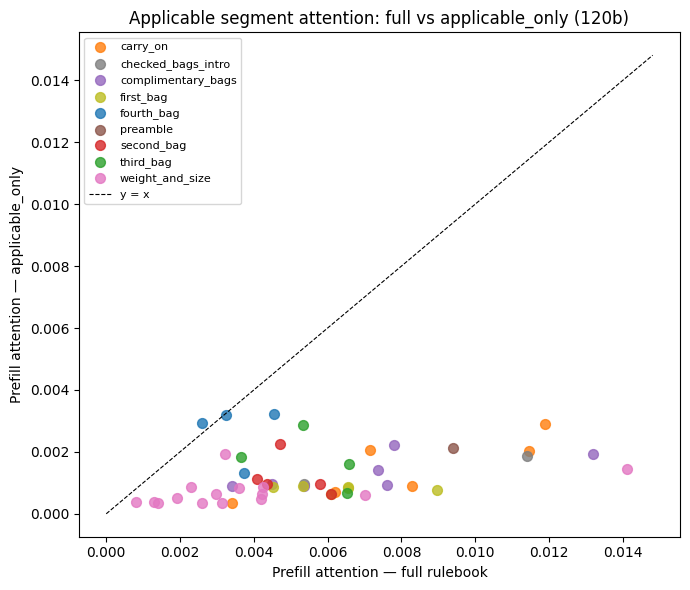

Median attention ratio (applicable_only / full): 0.20x
Segments with higher attn in app_only: 1 / 50


In [9]:
# Scatter: attn_full vs attn_app per segment (each point = one segment, avg across samples)
fig, ax = plt.subplots(figsize=(7, 6))
for sec, grp in seg_compare.groupby("section"):
    ax.scatter(grp["attn_full"], grp["attn_app"],
               label=sec, color=sec_color.get(sec, "gray"), s=50, alpha=0.8)

lim_max = max(seg_compare[["attn_full", "attn_app"]].max()) * 1.05
ax.plot([0, lim_max], [0, lim_max], "k--", lw=0.8, label="y = x")
ax.set_xlabel("Prefill attention — full rulebook")
ax.set_ylabel("Prefill attention — applicable_only")
ax.set_title("Applicable segment attention: full vs applicable_only (120b)")
ax.legend(fontsize=8, loc="upper left")
plt.tight_layout()
fig.savefig(FIGURES_DIR / "seg_attn_scatter.png", dpi=150, bbox_inches="tight")
plt.show()

# How much higher is attention in applicable_only?
median_ratio = seg_compare["ratio_app_over_full"].median()
print(f"Median attention ratio (applicable_only / full): {median_ratio:.2f}x")
print(f"Segments with higher attn in app_only: {(seg_compare['ratio_app_over_full'] > 1).sum()} / {len(seg_compare)}")

## 7. Attention concentration and accuracy

/tmp/ipykernel_10680/608834597.py:15: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([c, w] if len(w) else [c], labels=["Correct", "Incorrect"][:2 if len(w) else 1])
/tmp/ipykernel_10680/608834597.py:15: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([c, w] if len(w) else [c], labels=["Correct", "Incorrect"][:2 if len(w) else 1])


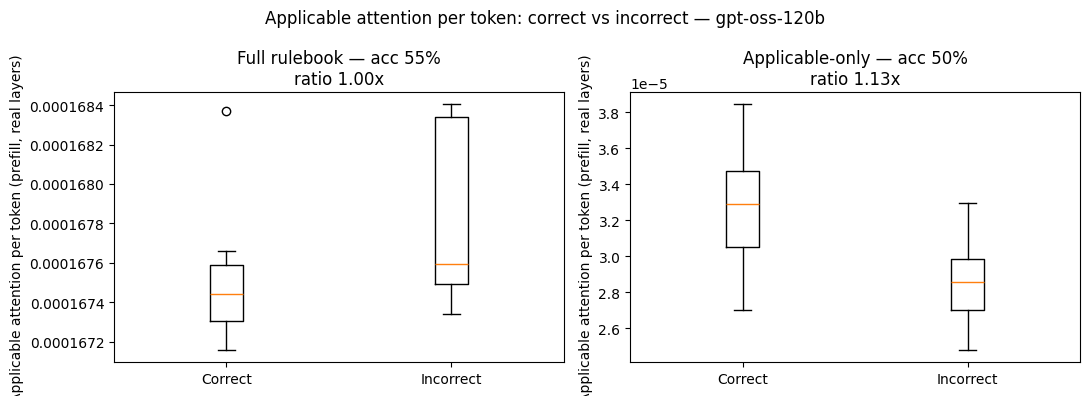

In [10]:
# Per-sample applicable per-token attention vs correctness
app_ptok_app = np.array([
    pf_app.sum() / max(sum(s["segment_num_tokens"]), 1)
    for s, pf_app in zip(app_samples, app_prefill)
])

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

for ax, ptok, is_correct, title in [
    (axes[0], full_app_ptok, is_correct_full, f"Full rulebook — acc {is_correct_full.mean():.0%}"),
    (axes[1], app_ptok_app,  is_correct_app,  f"Applicable-only — acc {is_correct_app.mean():.0%}"),
]:
    c = ptok[is_correct]
    w = ptok[~is_correct]
    ax.boxplot([c, w] if len(w) else [c], labels=["Correct", "Incorrect"][:2 if len(w) else 1])
    ax.set_ylabel("Applicable attention per token (prefill, real layers)")
    ax.set_title(title)
    if len(c) and len(w):
        ax.set_title(title + f"\nratio {c.mean()/max(w.mean(),1e-12):.2f}x")

plt.suptitle("Applicable attention per token: correct vs incorrect — gpt-oss-120b")
plt.tight_layout()
fig.savefig(FIGURES_DIR / "attn_vs_accuracy_120b.png", dpi=150, bbox_inches="tight")
plt.show()

In [11]:
# Summary table
rows = []
for label, ptok, is_correct, app_frac in [
    ("full",           full_app_ptok, is_correct_full, full_app_frac),
    ("applicable_only", app_ptok_app,  is_correct_app,  np.ones(len(app_samples))),
]:
    c, w = ptok[is_correct], ptok[~is_correct]
    rows.append({
        "condition":                    label,
        "accuracy":                     f"{is_correct.mean():.0%}",
        "avg applicable_attn_fraction": f"{app_frac.mean():.1%}",
        "app_per_tok (correct)":   f"{c.mean():.3e}" if len(c) else "—",
        "app_per_tok (incorrect)": f"{w.mean():.3e}" if len(w) else "—",
        "correct/incorrect ratio":  f"{c.mean()/max(w.mean(),1e-12):.2f}x" if len(c) and len(w) else "—",
    })

pd.DataFrame(rows).set_index("condition")

,accuracy,avg applicable_attn_fraction,app_per_tok (correct),app_per_tok (incorrect),correct/incorrect ratio
condition,,,,,
full,55%,49.5%,1.675e-04,1.679e-04,1.00x
applicable_only,50%,100.0%,3.240e-05,2.875e-05,1.13x
